In [0]:
JSOuser_df =spark.read.option("multiline", True).json("/Volumes/abc/upload_d/a_volume/users_extended.json")

In [0]:
user_df.show(3)

+-------------------+-----+--------------------+-----------+------------+-------+
|            address| name|         preferences|signup_date|subscription|user_id|
+-------------------+-----+--------------------+-----------+------------+-------+
|  {Chennai, 903618}|User1|{[Documentary, Co...| 2022-11-01|    Standard|     u1|
|   {Mumbai, 438363}|User2|{[Action, Drama],...| 2022-02-06|    Standard|     u2|
|{Hyderabad, 107835}|User3|{[Documentary, Ac...| 2022-01-21|     Premium|     u3|
+-------------------+-----+--------------------+-----------+------------+-------+
only showing top 3 rows


In [0]:
videos_df =spark.read.option("multiline", True).json("/Volumes/abc/upload_d/a_volume/videos_extended.json")

In [0]:
videos_df.show(3)

+--------------------+--------+--------+-----------+------+--------+
|                cast|duration|   genre|    ratings| title|video_id|
+--------------------+--------+--------+-----------+------+--------+
|[{Actor6, Support...|     124|Thriller|{2.4, 1361}|Video1|      v1|
|[{Actor16, Lead},...|      58|   Drama|{4.0, 1787}|Video2|      v2|
|   [{Actor12, Lead}]|     175|Thriller|{3.8, 1741}|Video3|      v3|
+--------------------+--------+--------+-----------+------+--------+
only showing top 3 rows


In [0]:
logs_df =spark.read.option("multiline", True).json("/Volumes/abc/upload_d/a_volume/viewing_logs_extended.json")

In [0]:
logs_df.show(3)

+--------------------+-------+--------+----------+---------------+
|              device|user_id|video_id| view_date|watched_minutes|
+--------------------+-------+--------+----------+---------------+
|{4.1.7, Windows, ...|    u10|      v5|2023-05-25|             63|
|    {1.6.8, iOS, TV}|    u18|     v79|2023-04-19|             70|
|{5.7.0, iOS, Laptop}|    u44|     v23|2023-04-14|            105|
+--------------------+-------+--------+----------+---------------+
only showing top 3 rows


In [0]:
user_df.select("preferences").show(3)

+--------------------+
|         preferences|
+--------------------+
|{[Documentary, Co...|
|{[Action, Drama],...|
|{[Documentary, Ac...|
+--------------------+
only showing top 3 rows


In [0]:
user_df.printSchema()

root
 |-- address: struct (nullable = true)
 |    |-- city: string (nullable = true)
 |    |-- zip: string (nullable = true)
 |-- name: string (nullable = true)
 |-- preferences: struct (nullable = true)
 |    |-- genres: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- notifications: boolean (nullable = true)
 |-- signup_date: string (nullable = true)
 |-- subscription: string (nullable = true)
 |-- user_id: string (nullable = true)



In [0]:
videos_df.printSchema()

root
 |-- cast: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- name: string (nullable = true)
 |    |    |-- role: string (nullable = true)
 |-- duration: long (nullable = true)
 |-- genre: string (nullable = true)
 |-- ratings: struct (nullable = true)
 |    |-- average: double (nullable = true)
 |    |-- votes: long (nullable = true)
 |-- title: string (nullable = true)
 |-- video_id: string (nullable = true)



In [0]:
logs_df.printSchema()

root
 |-- device: struct (nullable = true)
 |    |-- app_version: string (nullable = true)
 |    |-- os: string (nullable = true)
 |    |-- type: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- video_id: string (nullable = true)
 |-- view_date: string (nullable = true)
 |-- watched_minutes: long (nullable = true)



In [0]:
user_df.select("address").show(4)

+-------------------+
|            address|
+-------------------+
|  {Chennai, 903618}|
|   {Mumbai, 438363}|
|{Hyderabad, 107835}|
|{Hyderabad, 528387}|
+-------------------+
only showing top 4 rows


In [0]:
user_df.select("address.city").show(4)

+---------+
|     city|
+---------+
|  Chennai|
|   Mumbai|
|Hyderabad|
|Hyderabad|
+---------+
only showing top 4 rows


In [0]:
from pyspark.sql.functions import col,explode
user_flat = user_df.select("user_id", 
                           "name",
                           "signup_date",
                           "subscription",  
                           col("address.city").alias("city"), 
                           col("address.zip").alias("zip"),
                           col("preferences.genres").alias("preferred_genres"),
                           col("preferences.notifications").alias("notifications_enabled"))
user_flat.show(5,truncate=False)
user_flat.printSchema()

+-------+-----+-----------+------------+---------+------+---------------------+---------------------+
|user_id|name |signup_date|subscription|city     |zip   |preferred_genres     |notifications_enabled|
+-------+-----+-----------+------------+---------+------+---------------------+---------------------+
|u1     |User1|2022-11-01 |Standard    |Chennai  |903618|[Documentary, Comedy]|false                |
|u2     |User2|2022-02-06 |Standard    |Mumbai   |438363|[Action, Drama]      |false                |
|u3     |User3|2022-01-21 |Premium     |Hyderabad|107835|[Documentary, Action]|true                 |
|u4     |User4|2022-03-04 |Premium     |Hyderabad|528387|[Thriller, Action]   |false                |
|u5     |User5|2022-11-29 |Standard    |Delhi    |425817|[Action, Thriller]   |true                 |
+-------+-----+-----------+------------+---------+------+---------------------+---------------------+
only showing top 5 rows
root
 |-- user_id: string (nullable = true)
 |-- name: str

In [0]:
videos_flat= videos_df.select("video_id", 
                           "title",
                           "genre",
                           "cast",
                           "duration",
                           col("ratings.average").alias("average_rating"),
                           col("ratings.votes").alias("vote_count"),
                           explode("cast").alias("cast_member")
                           ).select(
                                "video_id", 
                                "title",
                                "genre",
                                "duration",
                                "average_rating",
                                "vote_count",
                                col("cast_member.name").alias("actor_name"),
                                col("cast_member.role").alias("actor_role")
                            )
videos_flat.show(5,truncate=False)



+--------+------+--------+--------+--------------+----------+----------+----------+
|video_id|title |genre   |duration|average_rating|vote_count|actor_name|actor_role|
+--------+------+--------+--------+--------------+----------+----------+----------+
|v1      |Video1|Thriller|124     |2.4           |1361      |Actor6    |Supporting|
|v1      |Video1|Thriller|124     |2.4           |1361      |Actor6    |Supporting|
|v2      |Video2|Drama   |58      |4.0           |1787      |Actor16   |Lead      |
|v2      |Video2|Drama   |58      |4.0           |1787      |Actor12   |Lead      |
|v3      |Video3|Thriller|175     |3.8           |1741      |Actor12   |Lead      |
+--------+------+--------+--------+--------------+----------+----------+----------+
only showing top 5 rows


In [0]:
logs_flat = logs_df.select(
    "user_id",
    "video_id",
    "watched_minutes",
    "view_date",
    col("device.type").alias("device_type"),
    col("device.os").alias("device_os"),
    col("device.app_version").alias("app_version")
)
logs_flat.show(5,truncate=False)

+-------+--------+---------------+----------+-----------+---------+-----------+
|user_id|video_id|watched_minutes|view_date |device_type|device_os|app_version|
+-------+--------+---------------+----------+-----------+---------+-----------+
|u10    |v5      |63             |2023-05-25|Tablet     |Windows  |4.1.7      |
|u18    |v79     |70             |2023-04-19|TV         |iOS      |1.6.8      |
|u44    |v23     |105            |2023-04-14|Laptop     |iOS      |5.7.0      |
|u19    |v23     |5              |2023-04-07|Mobile     |Windows  |2.2.1      |
|u30    |v98     |12             |2023-05-19|Mobile     |macOS    |3.3.1      |
+-------+--------+---------------+----------+-----------+---------+-----------+
only showing top 5 rows


In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, countDistinct,sum,count

result_df = logs_flat.groupBy("device_type", "device_os") \
              .agg(
                  count("*").alias("session_count"),
                  sum("watched_minutes").alias("total_watched_minutes")) \
              .orderBy(col("total_watched_minutes").desc())

# Show result
result_df.show()


+-----------+---------+-------------+---------------------+
|device_type|device_os|session_count|total_watched_minutes|
+-----------+---------+-------------+---------------------+
|     Mobile|  Android|           62|                 3901|
|     Laptop|  Android|           56|                 3871|
|     Tablet|    Linux|           53|                 3226|
|     Tablet|      iOS|           56|                 3121|
|     Laptop|      iOS|           52|                 2848|
|     Tablet|  Windows|           53|                 2835|
|         TV|    macOS|           50|                 2800|
|     Mobile|    macOS|           46|                 2758|
|         TV|  Android|           51|                 2716|
|     Tablet|  Android|           49|                 2620|
|     Mobile|    Linux|           53|                 2587|
|     Laptop|  Windows|           54|                 2493|
|     Laptop|    Linux|           53|                 2447|
|     Laptop|    macOS|           53|   

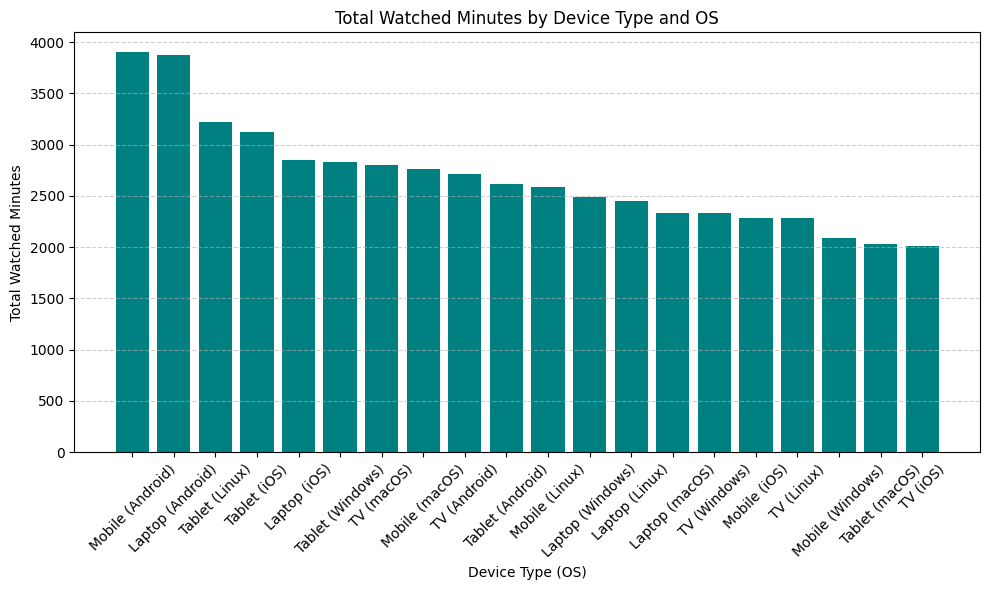

In [0]:
import matplotlib.pyplot as plt

device_pd = result_df.toPandas()
plt.figure(figsize=(10, 6))
device_pd["label"] =device_pd['device_type'] + ' (' + device_pd['device_os'] + ')'
plt.bar(device_pd["label"],device_pd['total_watched_minutes'], color ='teal')
plt.title('Total Watched Minutes by Device Type and OS')
plt.xlabel('Device Type (OS)')
plt.ylabel('Total Watched Minutes'  )
plt.xticks(rotation=45)
plt.grid(True , axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [0]:
# genre popularity Weighted by Watch Timev

from pyspark.sql.functions import col,when
genre_popularity=logs_flat.join(videos_flat,logs_flat.video_id==videos_flat.video_id)\
    .groupBy("genre")\
    .agg(sum("watched_minutes").alias("total_minutes"),countDistinct("user_id").alias("total_users"))\
    .withColumn("weighted_popularity",(col("total_minutes")/col("total_users")).alias("weighted_popularity"))\
    .orderBy("weighted_popularity",ascending=False)
display(genre_popularity)

genre,total_minutes,total_users,weighted_popularity
Sci-Fi,23048,49,470.3673469387755
Comedy,21668,50,433.36
Drama,15529,50,310.58
Action,14105,47,300.1063829787234
Thriller,13976,49,285.2244897959184
Documentary,9639,50,192.78


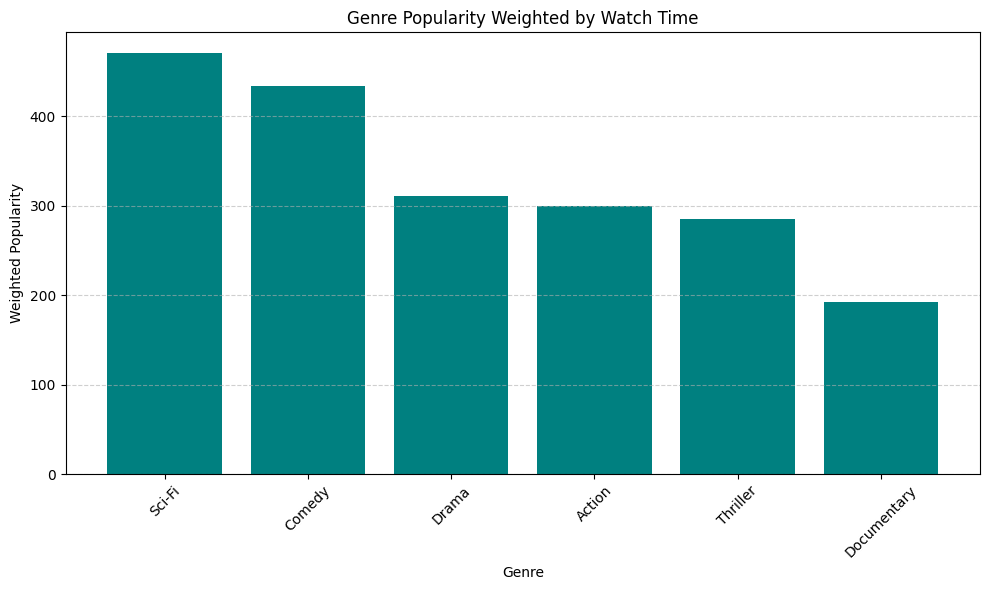

In [0]:
genre_popularity_pd = genre_popularity.toPandas()genre_popularity_pd = genre_popularity.toPandas()
plt.figure(figsize=(10, 6))
plt.bar(genre_popularity_pd["genre"]    ,genre_popularity_pd['weighted_popularity'], color ="teal")
plt.title('Genre Popularity Weighted by Watch Time')
plt.xlabel('Genre')
plt.ylabel('Weighted Popularity'  )
plt.xticks(rotation=45)
plt.grid(True , axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [0]:
from pyspark.sql.functions import max,datediff ,current_date

In [0]:
last_seen =logs_flat.groupBy("user_id")\
    .agg(max("view_date").alias("last_activity"))

churn_feature_df = user_flat.join(last_seen, "user_id","left")\
    .withColumn("days_since_last_view",datediff(current_date(),"last_activity"))

churn_feature_df.select("user_id","subscription","days_since_last_view").show(5)

+-------+------------+--------------------+
|user_id|subscription|days_since_last_view|
+-------+------------+--------------------+
|     u1|    Standard|                 746|
|     u6|     Premium|                 743|
|     u5|    Standard|                 753|
|     u3|     Premium|                 746|
|     u2|    Standard|                 755|
+-------+------------+--------------------+
only showing top 5 rows


In [0]:
# identify user watch 2+ shows withiin a single day
from pyspark.sql.functions import count
from pyspark.sql.window import Window

binge_window = Window.partitionBy("user_id","view_date")

binge_sessions = logs_flat.withColumn("views_per_day",count("*").over(binge_window))\
    .filter("views_per_day >=2")\
    .select("user_id","view_date","views_per_day").distinct()


binge_sessions.show(5)


                                               

+-------+----------+-------------+
|user_id| view_date|views_per_day|
+-------+----------+-------------+
|     u1|2023-01-10|            2|
|    u10|2023-05-25|            2|
|    u12|2023-06-05|            2|
|    u13|2023-01-14|            2|
|    u14|2023-01-23|            2|
+-------+----------+-------------+
only showing top 5 rows


In [0]:
#determnie which cities with the highest content consumption

geo_watch_stats =logs_flat.join(user_flat,"user_id")\
    .groupBy("city")\
    .agg(sum("watched_minutes").alias("total_watch_time"))\
    .orderBy("total_watch_time",ascending= False)


geo_watch_stats.show(5)


+---------+----------------+
|     city|total_watch_time|
+---------+----------------+
|    Delhi|           13253|
|Hyderabad|           12696|
|   Mumbai|           11376|
|Bangalore|           10435|
|  Chennai|            5847|
+---------+----------------+



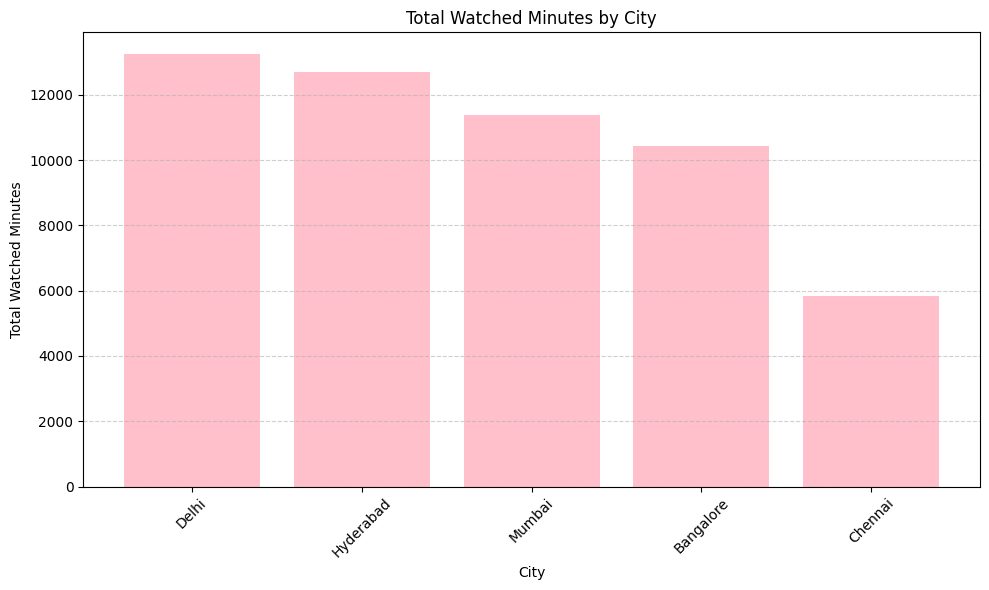

In [0]:
geo_watch_stats_pd= geo_watch_stats.toPandas()
plt.figure(figsize=(10, 6))
plt.bar(geo_watch_stats_pd["city"],geo_watch_stats_pd['total_watch_time'], color ='pink')
plt.title('Total Watched Minutes by City')
plt.xlabel('City')
plt.ylabel('Total Watched Minutes'  )
plt.xticks(rotation=45)
plt.grid(True , axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
